# 15b — Lasso Regularization Path

A small (`n=15`, `5` predictors) inline regression example, used to build
the classic lasso **coefficient path** diagram: as the penalty relaxes
from "fully shrunk" to "unregularized OLS", each coefficient traces a
path from 0 out to its OLS value, and the number of non-zero coefficients
(the model's degrees of freedom) increases in discrete jumps.

The **penalized-form** lasso (`min ||y-Xβ||² + λ||β||₁`) is solved here
using `quanttoolbox.stats.regression.lasso.lasso_ccd`, via cyclical
coordinate descent. Looping it over a grid of `λ` values traces out the
regularization path; `τ = Σ|β|` (the L1 norm) and `df = #{|β|≥ε}` are then
computed directly from each path point.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from quanttoolbox.stats.regression.lasso import lasso_regularization_path

color_skyblue    = "#87ceeb"
color_red        = "#d62728"
color_green      = "#2ca02c"
color_violet     = "#ff33ff"
color_darkyellow = "#b8860b"
color_black      = "#000000"

plt.rcParams["figure.dpi"] = 100

data = np.array([
    [3.1,  2.8, 4.3, 0.3, 2.2, 3.5],
    [24.9, 5.9, 3.6, 3.2, 0.7, 6.4],
    [27.3, 6.0, 9.6, 7.6, 9.5, 0.9],
    [25.4, 8.4, 5.4, 1.8, 1.0, 7.1],
    [46.1, 5.2, 7.6, 8.3, 0.6, 4.5],
    [45.7, 6.0, 7.0, 9.6, 0.6, 0.6],
    [47.4, 6.1, 1.0, 8.5, 9.6, 8.6],
    [-1.8, 1.2, 9.6, 2.7, 4.8, 5.8],
    [20.8, 3.2, 5.0, 4.2, 2.7, 3.6],
    [6.8,  0.5, 9.2, 6.9, 9.3, 0.7],
    [12.9, 7.9, 9.1, 1.0, 5.9, 5.4],
    [37.0, 1.8, 1.3, 9.2, 6.1, 8.3],
    [14.7, 7.4, 5.6, 0.9, 5.6, 3.9],
    [-3.2, 2.3, 6.6, 0.0, 3.6, 6.4],
    [44.3, 7.7, 2.2, 6.5, 1.3, 0.7],
])
y_raw = data[:, 0]
x_raw = data[:, 1:6]


def standardize(a):
    a = np.asarray(a, dtype=float)
    if a.ndim == 1:
        return (a - a.mean()) / a.std(ddof=0)
    return (a - a.mean(axis=0)) / a.std(axis=0, ddof=0)


y = standardize(y_raw)
x = standardize(x_raw)
m = x.shape[1]

beta_ols = np.linalg.inv(x.T @ x) @ x.T @ y
print("OLS coefficients:", np.round(beta_ols, 4))


OLS coefficients: [ 0.4586 -0.1849  0.8336 -0.1893  0.0931]


## Table: coefficients, shrinkage `τ`, RSS, `R²`, and degrees of freedom
across 5 representative `λ` values.


In [2]:
lambda_table = np.array([0, 0.9, 2.5, 5.5, 7.5])
path_table = lasso_regularization_path(y, x, lambda_table)
beta_table, tau_table, df_table, complexity_table = (
    path_table.beta, path_table.l1_norm, path_table.df, path_table.complexity
)

u = y[:, None] - x @ beta_table.T
rss = np.mean(u**2, axis=0)
tss = np.mean(y**2)
R2 = 1 - rss / tss

import pandas as pd

results = pd.DataFrame({
    "lambda": lambda_table,
    **{f"beta{j+1}": beta_table[:, j] for j in range(m)},
    "tau": tau_table,
    "rss": rss,
    "R2": R2,
    "df": df_table,
})
results.round(4)

,lambda,beta1,beta2,beta3,beta4,beta5,tau,rss,R2,df
0,0.0,0.4586,-0.1849,0.8336,-0.1893,0.0931,1.7595,0.0126,0.9874,5
1,0.9,0.4054,-0.2028,0.7315,-0.1144,0.0000,1.4541,0.0308,0.9692,4
2,2.5,0.3254,-0.1474,0.6088,-0.0106,0.0000,1.0922,0.1128,0.8872,4
3,5.5,0.1389,-0.0110,0.4207,-0.0000,0.0000,0.5706,0.3893,0.6107,3
4,7.5,0.0000,-0.0000,0.2819,-0.0000,0.0000,0.2819,0.6386,0.3614,1


In [3]:
print(f"At lambda=0, lasso beta matches OLS: {np.allclose(beta_table[0], beta_ols, atol=1e-3)}")
print(f"tau is monotonically decreasing in lambda: {bool(np.all(np.diff(tau_table) <= 1e-9))}")
print(f"df is non-increasing in lambda: {bool(np.all(np.diff(df_table) <= 0))}")
print(f"R2 is non-increasing in lambda (more shrinkage can only fit the data worse in-sample): {bool(np.all(np.diff(R2) <= 1e-9))}")

At lambda=0, lasso beta matches OLS: True
tau is monotonically decreasing in lambda: True
df is non-increasing in lambda: True
R2 is non-increasing in lambda (more shrinkage can only fit the data worse in-sample): True


## Full regularization path

A fine `λ` grid (`0` to `100`) traces each coefficient's full path against
the normalized shrinkage fraction `s = τ/τ_max` (`τ_max = τ(λ=0)`, the
unconstrained OLS L1-norm) — the classic lasso path diagram, with the
degrees-of-freedom "steps" shaded and numbered along the bottom.

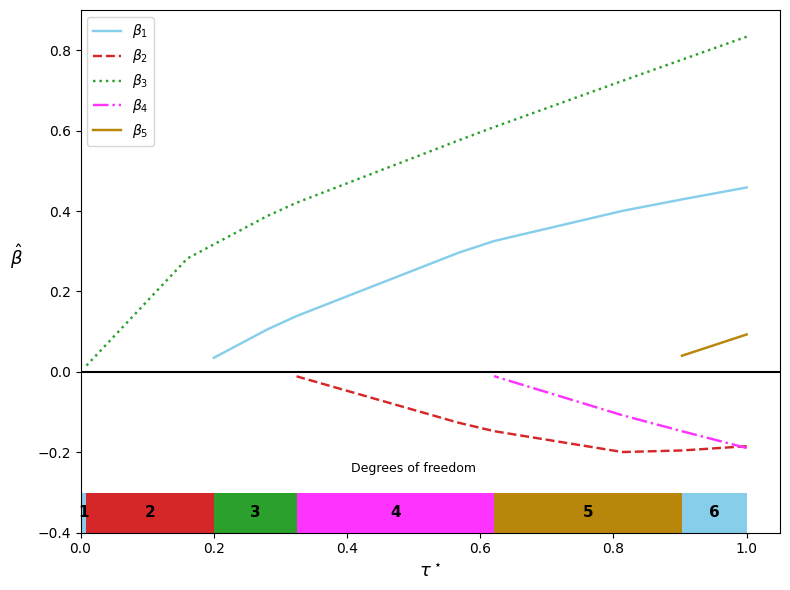

Number of distinct df 'steps' visited as lambda relaxes from 100.0 to 0: 6
df at lambda=0 (s=1, rightmost): 5  (should be m=5, all variables active)
df at lambda=100.0 (s~0, leftmost): 0  (heaviest shrinkage shown)


In [4]:
lambda_fine = np.concatenate([np.arange(0, 50.01, 0.5), [60, 70, 80, 90, 100]])
path_fine = lasso_regularization_path(y, x, lambda_fine, n_iters=1000)
beta_fine, tau_fine, df_fine = path_fine.beta, path_fine.l1_norm, path_fine.df

s = tau_fine / tau_fine[0]
beta_fine_masked = np.where(np.abs(beta_fine) <= 1e-6, np.nan, beta_fine)

fig, ax = plt.subplots(figsize=(8, 6))
styles = ["-", "--", ":", "-.", "-"]
colors = [color_skyblue, color_red, color_green, color_violet, color_darkyellow]
for j in range(m):
    ax.plot(s, beta_fine_masked[:, j], styles[j], color=colors[j], linewidth=1.75, label=rf"$\beta_{{{j+1}}}$")

# Mark the degrees-of-freedom "steps": where df changes as s decreases from 1 (lambda=0) to 0.
change_idx = np.where(np.diff(df_fine) != 0)[0]
s_cut = np.sort(np.concatenate([[0.0], s[change_idx], [1.0]]))
for i in range(len(s_cut) - 1):
    width = s_cut[i + 1] - s_cut[i]
    ax.add_patch(plt.Rectangle((s_cut[i], -0.4), width, 0.1, facecolor=colors[i % len(colors)], edgecolor="none"))
    ax.text(s_cut[i] + width / 2, -0.35, str(i + 1), fontweight="bold", fontsize=11, ha="center", va="center")

ax.text(0.5, -0.25, "Degrees of freedom", fontsize=9, ha="center")
ax.axhline(0, color=color_black, linewidth=1.5)
ax.set_xlim(0, 1.05)
ax.set_ylim(-0.4, 0.9)
ax.set_xlabel(r"$\tau^\star$", fontsize=13)
ax.set_ylabel(r"$\hat{\beta}$", fontsize=13, rotation=0, labelpad=15)
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

print(f"Number of distinct df 'steps' visited as lambda relaxes from {lambda_fine[-1]} to 0: {len(s_cut)-1}")
print(f"df at lambda=0 (s=1, rightmost): {df_fine[0]}  (should be m={m}, all variables active)")
print(f"df at lambda={lambda_fine[-1]} (s~0, leftmost): {df_fine[-1]}  (heaviest shrinkage shown)")